# 02 — Bias Detection & Fairness Analysis

**Course:** Data Ecosystems and Governance in Organizations  
**Company:** NovaCred (fictional fintech)  
**Role:** Data Scientist  

---

## Objectives

This notebook investigates whether NovaCred's credit-scoring algorithm exhibits bias against protected groups. Specifically, we:

1. Compute the **Disparate Impact (DI) ratio** for gender and test against the four-fifths rule
2. Analyse **age-based** approval patterns
3. Explore **interaction effects** between gender and age
4. Investigate **proxy discrimination** — non-protected variables that may encode protected characteristics

> **Input:** `../data/cleaned_credit_applications.csv` (produced by `01-data-quality.ipynb`)

---
## 1. Setup

Import libraries and load the cleaned dataset.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Colour palette — usada em todos os gráficos
PALETTE = {"Female": "#e07b7b", "Male": "#7bbde0"}
THRESHOLD_COLOR = "#d62728"  # vermelho para a linha DI = 0.80

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [19]:
df = pd.read_csv("../data/cleaned_credit_applications.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (500, 29)
Columns: ['_id', 'full_name', 'email', 'ssn', 'ip_address', 'gender', 'gender_raw', 'date_of_birth', 'date_of_birth_raw', 'age', 'zip_code', 'annual_income', 'annual_income_raw', 'income_imputed', 'credit_history_months', 'credit_history_months_flag', 'debt_to_income', 'dti_flag', 'savings_balance', 'loan_approved', 'interest_rate', 'approved_amount', 'rejection_reason', 'total_spending', 'alcohol_spend', 'email_missing', 'ssn_missing', 'dob_missing', 'ssn_conflict']


In [2]:
df.head()

,_id,full_name,email,ssn,ip_address,gender,gender_raw,date_of_birth,date_of_birth_raw,age,...,loan_approved,interest_rate,approved_amount,rejection_reason,total_spending,alcohol_spend,email_missing,ssn_missing,dob_missing,ssn_conflict
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,Male,2001-03-09,2001-03-09,24.0,...,False,NaN,NaN,algorithm_risk_score,1517,247,False,False,False,False
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,M,1992-03-31,1992-03-31,33.0,...,False,NaN,NaN,algorithm_risk_score,947,0,False,False,False,False
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,Male,1989-10-24,1989-10-24,36.0,...,True,3.7,59000.0,NaN,109,0,False,False,False,False
3,app_024,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,Male,1983-04-25,1983-04-25,42.0,...,True,4.3,34000.0,NaN,575,0,False,False,False,False
4,app_184,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,M,1999-05-21,1999-05-21,26.0,...,False,NaN,NaN,algorithm_risk_score,463,0,False,False,False,False


In [20]:
# data check
key_cols = ["gender", "age", "loan_approved", "annual_income",
            "credit_history_months", "zip_code", "alcohol_spend"]

print("Null counts in key columns:")
print(df[key_cols].isnull().sum())
print()
print("Gender distribution (after cleaning):")
print(df["gender"].value_counts())
print()
print("Loan approved distribution:")
print(df["loan_approved"].value_counts())
print(f"\nOverall approval rate: {df['loan_approved'].mean():.1%}")

Null counts in key columns:
gender                   2
age                      4
loan_approved            0
annual_income            0
credit_history_months    0
zip_code                 1
alcohol_spend            0
dtype: int64

Gender distribution (after cleaning):
gender
Female    251
Male      247
Name: count, dtype: int64

Loan approved distribution:
loan_approved
True     292
False    208
Name: count, dtype: int64

Overall approval rate: 58.4%


---
## 2. Gender Disparate Impact

The **Disparate Impact (DI) ratio** measures whether an unprivileged group receives positive outcomes at a significantly lower rate than a privileged group.

$$DI = \frac{\text{Approval rate (Female)}}{\text{Approval rate (Male)}}$$

The **four-fifths rule** (80% rule) is the standard legal threshold:
- DI **< 0.80** → potential disparate impact (violation)
- DI **≥ 0.80** → no disparate impact detected

In [21]:
approval_by_gender = (
    df.groupby("gender")["loan_approved"]
      .agg(["count", "mean"])
      .rename(columns={"count": "n_applications", "mean": "approval_rate"})
)

print(approval_by_gender)

        n_applications  approval_rate
gender                               
Female             251       0.505976
Male               247       0.659919


In [22]:
rate_female = approval_by_gender.loc["Female", "approval_rate"]
rate_male   = approval_by_gender.loc["Male",   "approval_rate"]

DI  = rate_female / rate_male
gap = rate_male - rate_female

print(f"Approval rate — Female: {rate_female:.1%}")
print(f"Approval rate — Male:   {rate_male:.1%}")
print(f"Approval gap:           {gap:.1%}")
print(f"Disparate Impact (DI):  {DI:.4f}")
print()
if DI < 0.8:
    print("⚠️  DI < 0.80 — POTENTIAL DISPARATE IMPACT DETECTED (four-fifths rule violated)")
else:
    print("✅  DI ≥ 0.80 — No disparate impact detected")

Approval rate — Female: 50.6%
Approval rate — Male:   66.0%
Approval gap:           15.4%
Disparate Impact (DI):  0.7667

⚠️  DI < 0.80 — POTENTIAL DISPARATE IMPACT DETECTED (four-fifths rule violated)


### Visualisation — Approval Rate by Gender

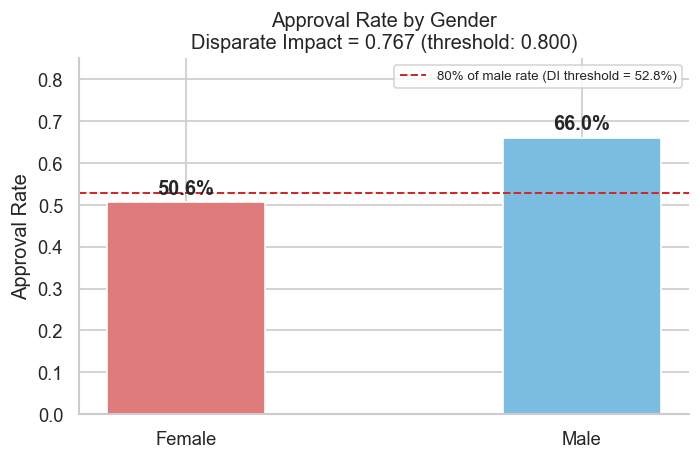

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))

genders = ["Female", "Male"]
rates   = [rate_female, rate_male]
colors  = [PALETTE["Female"], PALETTE["Male"]]

bars = ax.bar(genders, rates, color=colors, width=0.4, edgecolor="white")

# Linha do threshold DI = 0.80
threshold = 0.8 * rate_male
ax.axhline(threshold, color=THRESHOLD_COLOR, linestyle="--", linewidth=1.2,
           label=f"80% of male rate (DI threshold = {threshold:.1%})")

# Etiquetas em cima de cada barra
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{rate:.1%}", ha="center", va="bottom", fontweight="bold")

ax.set_ylim(0, 0.85)
ax.set_ylabel("Approval Rate")
ax.set_title(f"Approval Rate by Gender\nDisparate Impact = {DI:.3f} (threshold: 0.800)")
ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

---
## 3. Age-Based Bias

Age is a protected characteristic. We analyse whether approval rates differ significantly across age groups.

In [25]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[18, 29, 39, 49, 59, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"]
)

approval_by_age = (
    df.groupby("age_bin", observed=False)["loan_approved"]
      .agg(["count", "mean"])
      .rename(columns={"count": "n_applications", "mean": "approval_rate"})
)

print(approval_by_age)

         n_applications  approval_rate
age_bin                               
18-29                82       0.414634
30-39               171       0.567251
40-49               138       0.688406
50-59                62       0.564516
60+                  43       0.651163


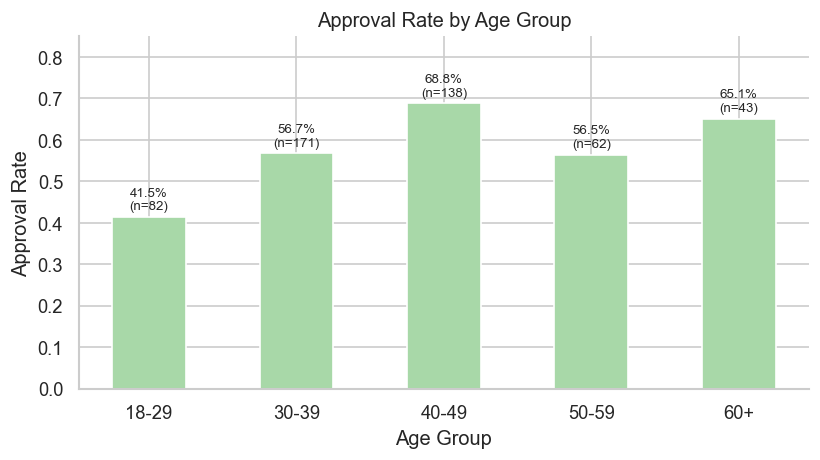

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    approval_by_age.index,
    approval_by_age["approval_rate"],
    color="#a8d8a8", edgecolor="white", width=0.5
)

for bar, (_, row) in zip(bars, approval_by_age.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{row['approval_rate']:.1%}\n(n={row['n_applications']:.0f})",
            ha="center", va="bottom", fontsize=8)

ax.set_ylim(0, 0.85)
ax.set_xlabel("Age Group")
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by Age Group")
sns.despine()
plt.tight_layout()
plt.show()

---
## 4. Interaction Effect: Gender × Age

A gender gap at the overall level may hide variation across age groups. Here we compute the DI ratio **within each age group** to detect where the bias is most severe.

In [27]:
approval_gender_age = (
    df.groupby(["age_bin", "gender"], observed=False)["loan_approved"]
      .mean()
      .unstack()
)

approval_gender_age["DI"] = approval_gender_age["Female"] / approval_gender_age["Male"]

print(approval_gender_age.round(3))

gender   Female   Male     DI
age_bin                      
18-29     0.341  0.500  0.682
30-39     0.488  0.644  0.758
40-49     0.618  0.757  0.816
50-59     0.467  0.645  0.723
60+       0.609  0.700  0.870


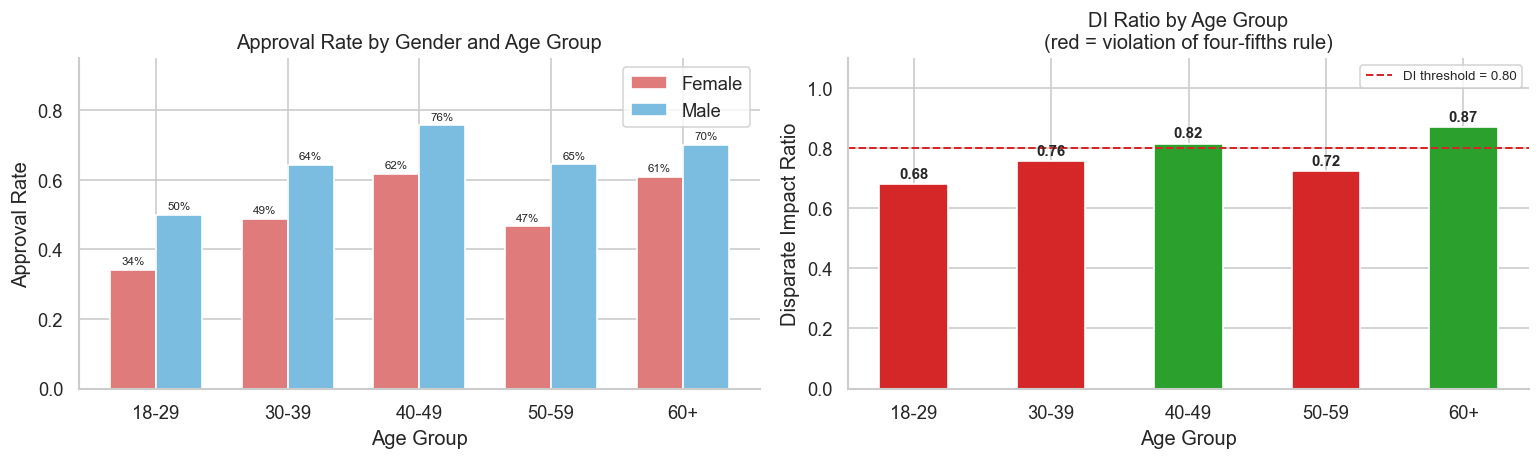

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Gráfico esquerdo: approval rate por género e age group ---
x = np.arange(len(approval_gender_age.index))
width = 0.35

ax = axes[0]
bars_f = ax.bar(x - width/2, approval_gender_age["Female"], width,
                label="Female", color=PALETTE["Female"], edgecolor="white")
bars_m = ax.bar(x + width/2, approval_gender_age["Male"], width,
                label="Male", color=PALETTE["Male"], edgecolor="white")

for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.0%}", ha="center", va="bottom", fontsize=7)
for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.0%}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(approval_gender_age.index)
ax.set_ylim(0, 0.95)
ax.set_xlabel("Age Group")
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by Gender and Age Group")
ax.legend()
sns.despine(ax=ax)

# --- Gráfico direito: DI por age group ---
ax2 = axes[1]
colors_di = [THRESHOLD_COLOR if v < 0.8 else "#2ca02c" for v in approval_gender_age["DI"]]
bars_di = ax2.bar(approval_gender_age.index, approval_gender_age["DI"],
                  color=colors_di, edgecolor="white", width=0.5)

ax2.axhline(0.8, color=THRESHOLD_COLOR, linestyle="--", linewidth=1.2, label="DI threshold = 0.80")

for bar, val in zip(bars_di, approval_gender_age["DI"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=9)

ax2.set_ylim(0, 1.1)
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Disparate Impact Ratio")
ax2.set_title("DI Ratio by Age Group\n(red = violation of four-fifths rule)")
ax2.legend(fontsize=8)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

---
## 5. Proxy Discrimination Analysis

A **proxy variable** is a non-protected attribute that is highly correlated with a protected characteristic (e.g. gender), which can introduce indirect discrimination even when gender is not explicitly used in the model.

We investigate two potential proxies:
- **ZIP code** — geographic location can encode the demographic composition of an area
- **Annual income** — could mask or mediate gender disparities

### 5.1 ZIP Code as a Proxy for Gender

In [31]:
zip_code_str = (
    df["zip_code"]
    .astype("string")
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
)
df["zip_prefix"] = zip_code_str.str[:3]

zip_summary = (
    df[df["gender"].isin(["Male", "Female"])]
    .groupby("zip_prefix")
    .agg(
        approval_rate=("loan_approved", "mean"),
        female_ratio=("gender", lambda x: (x == "Female").mean()),
        n=("loan_approved", "count")
    )
    .reset_index()
    .sort_values("approval_rate")
)

print(zip_summary.to_string(index=False))
print()
zip_corr = zip_summary["female_ratio"].corr(zip_summary["approval_rate"])
print(f"Correlation (female ratio vs approval rate): {zip_corr:.4f}")

zip_prefix  approval_rate  female_ratio   n
       902       0.517391      0.934783 230
       300       0.555556      0.444444  18
       100       0.644000      0.112000 250

Correlation (female ratio vs approval rate): -0.9442


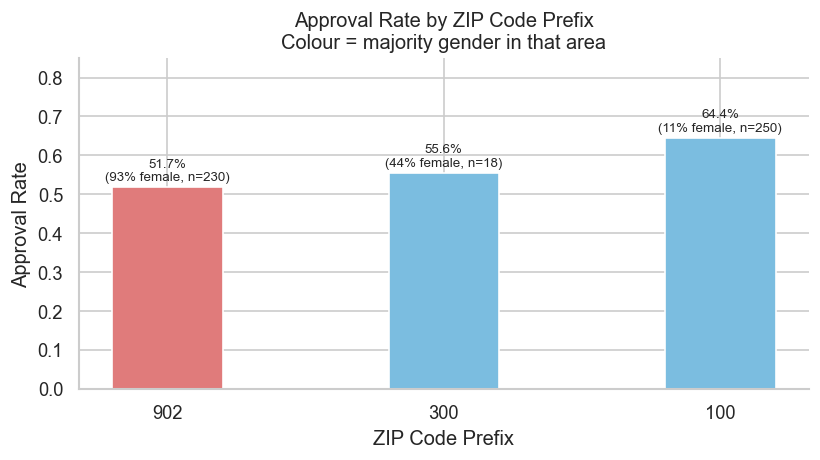

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))

colors_zip = [PALETTE["Female"] if r > 0.5 else PALETTE["Male"] for r in zip_summary["female_ratio"]]
bars = ax.bar(zip_summary["zip_prefix"], zip_summary["approval_rate"],
              color=colors_zip, edgecolor="white", width=0.4)

for bar, row in zip(bars, zip_summary.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row.approval_rate:.1%}\n({row.female_ratio:.0%} female, n={row.n})",
            ha="center", va="bottom", fontsize=8)

ax.set_ylim(0, 0.85)
ax.set_xlabel("ZIP Code Prefix")
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by ZIP Code Prefix\nColour = majority gender in that area")
sns.despine()
plt.tight_layout()
plt.show()

### 5.2 Income — Does the Gender Gap Persist After Controlling for Income?

If the gender gap were explained by income differences, we would expect it to disappear within each income quartile. We test this below.

In [33]:
df_gender = df[df["gender"].isin(["Male", "Female"])].copy()

print("Mean annual income by gender:")
print(df_gender.groupby("gender")["annual_income"].mean().apply(lambda x: f"${x:,.0f}"))
print()
print("Mean credit history (months) by gender:")
print(df_gender.groupby("gender")["credit_history_months"].mean().round(1))

Mean annual income by gender:
gender
Female    $83,866
Male      $81,437
Name: annual_income, dtype: object

Mean credit history (months) by gender:
gender
Female    51.2
Male      49.6
Name: credit_history_months, dtype: float64


**Key insight:** Female applicants have a slightly higher average income and longer credit history than male applicants. The gender gap therefore cannot be explained by financial profile, the bias is in the model itself.

In [34]:
df_valid = df_gender[df_gender["annual_income"].notna()].copy()
df_valid["annual_income"] = pd.to_numeric(df_valid["annual_income"], errors="coerce")
df_valid = df_valid[df_valid["annual_income"].notna()].copy()
df_valid["income_quartile"] = pd.qcut(
    df_valid["annual_income"], q=4,
    labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
)

di_income = (
    df_valid.groupby(["income_quartile", "gender"], observed=True)["loan_approved"]
    .mean()
    .unstack()
)
di_income["DI"] = di_income["Female"] / di_income["Male"]

print("Approval rate and DI by income quartile:")
print(di_income.round(3).to_string())

Approval rate and DI by income quartile:
gender           Female   Male     DI
income_quartile                      
Q1 (low)          0.323  0.507  0.636
Q2                0.435  0.729  0.598
Q3                0.644  0.738  0.872
Q4 (high)         0.618  0.685  0.901


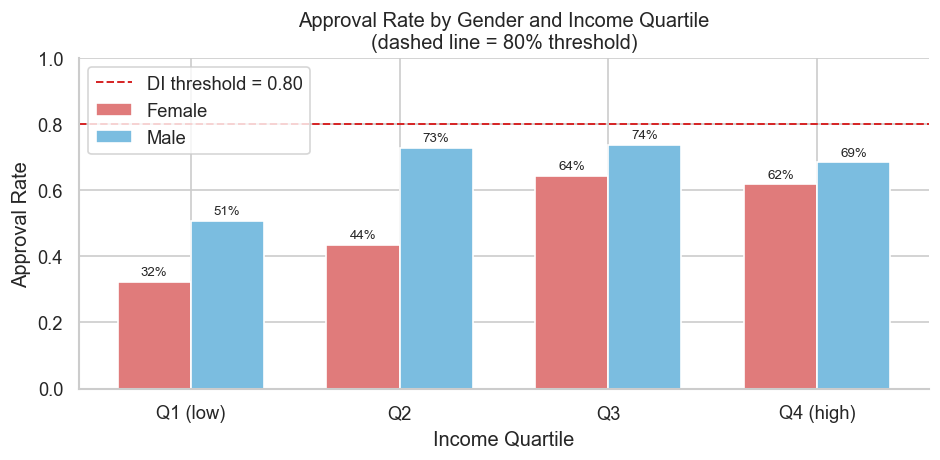

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(di_income.index))
width = 0.35

bars_f = ax.bar(x - width/2, di_income["Female"], width,
                label="Female", color=PALETTE["Female"], edgecolor="white")
bars_m = ax.bar(x + width/2, di_income["Male"], width,
                label="Male", color=PALETTE["Male"], edgecolor="white")

for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.0%}", ha="center", va="bottom", fontsize=8)
for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.0%}", ha="center", va="bottom", fontsize=8)

ax.axhline(0.8, color=THRESHOLD_COLOR, linestyle="--", linewidth=1.2,
           label="DI threshold = 0.80")
ax.set_xticks(x)
ax.set_xticklabels(di_income.index)
ax.set_ylim(0, 1.0)
ax.set_xlabel("Income Quartile")
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by Gender and Income Quartile\n(dashed line = 80% threshold)")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

---
## 6. Summary of Findings

A consolidated overview of all bias patterns detected in NovaCred's credit scoring algorithm.

| Finding | Metric | Threshold | Result |
|---|---|---|---|
| Gender Disparate Impact | DI = 0.767 | < 0.80 = violation | Violation |
| Age bias (18-29 group) | Approval rate = 41.5% | — | Lowest of all groups |
| Gender × Age (18-29) | DI = 0.68 | < 0.80 = violation | Most severe group |
| Gender × Age (50-59) | DI = 0.72 | < 0.80 = violation | Violation |
| ZIP code proxy | Corr = -0.94 | — | Strong proxy effect |
| Income as explanation | Female income > Male income | — | Does NOT explain the gap |
| Gender gap in Q1 income | DI = 0.64 | < 0.80 = violation | Most severe income group |

### Key Conclusions

1. **The algorithm exhibits statistically significant gender bias.** Female applicants are approved at a 15.4 percentage-point lower rate than male applicants (50.6% vs 66.0%), yielding a Disparate Impact ratio of 0.767, below the legal 0.80 threshold.

2. **The bias cannot be explained by financial profile.** Female applicants have slightly higher average income ($83 866 vs $81 437) and longer credit histories (51.2 vs 49.6 months), meaning the model is penalising gender itself, not financial risk.

3. **ZIP code is a strong proxy for gender** (correlation = -0.94). Areas with predominantly female applicants have significantly lower approval rates, this constitutes indirect discrimination under GDPR Article 22 and the EU AI Act.

4. **The bias is most severe for younger and lower-income female applicants.** DI drops to 0.68 for the 18-29 age group and to 0.60 for Q2 income, evidence of intersectional discrimination.